In [1]:
import stock_analyzer as sa
from sheet_worker import SheetWorker
import pandas as pd
from sklearn.linear_model import LinearRegression
import torch.nn as nn
import pytest  # For tests

# Init (idempotent)
worker = SheetWorker('mbook3.xlsx')
worker.read_symbols()
analyst = sa.StockAnalyzer(worker.symbols, '2024-07-24', '2025-07-24')

# Offline load
data = analyst.load_for_notebook(from_db=True)

In [2]:
data.loc[data['symbol']=='UXRP']

,symbol,last_update,last_close,rsi,macd,PE_Ratio,Dividend_Yield,Market_Cap,target_mean,target_high,target_low


In [3]:
# EDA/Analyticst
df = analyst.load_for_notebook(symbol='AAPL',from_db=True)
#print(df.describe())  # Stats

# ML: Simple regression test
X = df.index.astype(int).values.reshape(-1, 1)  # Time as feature
y = df['Close']
model = LinearRegression().fit(X[:-30], y[:-30])  # Train on past
preds = model.predict(X[-30:])  # Predict recent



In [ ]:
import auth

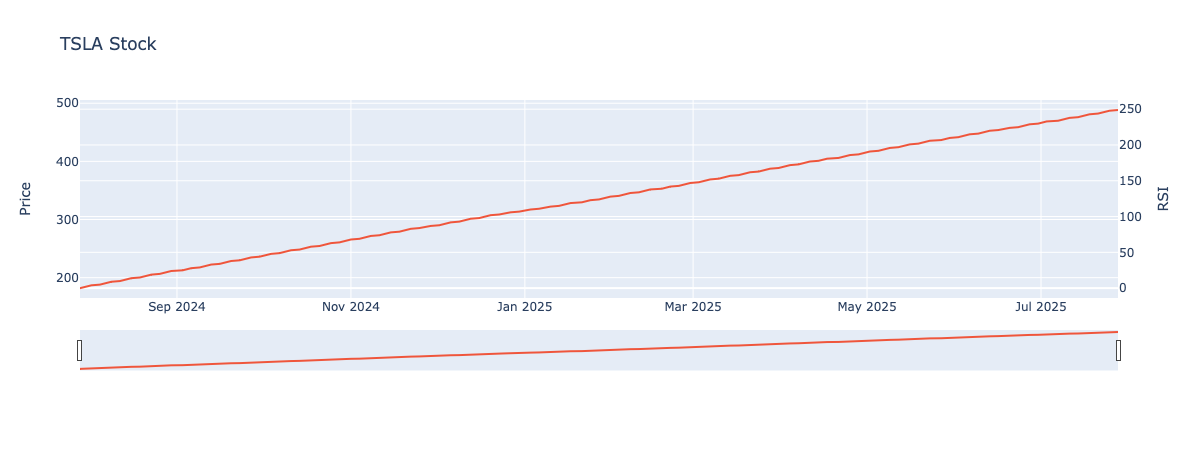

In [9]:
analyst.visualize('TSLA')

In [14]:
# Advanced ML: Torch LSTM (stub)
class StockLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 50, batch_first=True)
        self.fc = nn.Linear(50, 1)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h.squeeze(0))



In [13]:
# Train loop here...

# Regression Testing
@pytest.mark.parametrize("symbol", ['AAPL', 'GOOG'])
def test_data_load(symbol):
    assert not analyst.data[symbol].empty, f"Data missing for {symbol}"
# Run: !pytest